In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kuldeepjangra/global-supply-chain-disruption-dataset-20152026/weekly_timeline.csv
/kaggle/input/datasets/kuldeepjangra/global-supply-chain-disruption-dataset-20152026/weekly_route_operations.csv
/kaggle/input/datasets/kuldeepjangra/global-supply-chain-disruption-dataset-20152026/geopolitical_events.csv
/kaggle/input/datasets/kuldeepjangra/global-supply-chain-disruption-dataset-20152026/country_metadata.csv
/kaggle/input/datasets/kuldeepjangra/global-supply-chain-disruption-dataset-20152026/commodity_market.csv
/kaggle/input/datasets/kuldeepjangra/global-supply-chain-disruption-dataset-20152026/trade_routes.csv


# Introduction
**Why This Study Matters**

Modern economies depend on complex global supply chains that move goods, energy, and raw materials across continents every day. While globalization has improved efficiency and reduced costs, it has also increased vulnerability to disruptions.

Recent events such as the COVID-19 pandemic, the Russia–Ukraine conflict, the Red Sea shipping crisis, and tensions around the Strait of Hormuz have demonstrated how quickly geopolitical and economic shocks can spread through global trade networks.

Understanding these disruptions is critical for governments, businesses, investors, and logistics providers seeking to build resilient supply chains.

**Objective**

This notebook explores how global trade routes respond to geopolitical risks, commodity market shocks, and operational bottlenecks.

The goal is to uncover the hidden drivers of supply chain disruptions and identify patterns that distinguish resilient trade networks from vulnerable ones.

# Key Questions

This analysis aims to answer the following questions:

🌐 Trade Network Structure
* Which countries occupy the most critical positions in global trade networks?
* Are trade flows concentrated among a small number of routes?

🚢 Logistics Performance
* What factors contribute most to shipping delays?
* How does port congestion affect route performance?

⚔️ Geopolitical Risk
* How do geopolitical tensions influence freight costs and trade volumes?
* Are there risk thresholds beyond which disruptions accelerate?

📈 Market Dynamics
* How do commodity price shocks propagate through supply chains?
* Which crises created the largest operational impacts?

🤖 Predictive Intelligence
* Can future disruptions be forecast using historical patterns?
* Which routes remain resilient despite repeated shocks?* 

# Dataset Overview

The dataset consists of six interconnected tables covering global trade activity from 2015–2026.

File-------------------------------------Description
* country_metadata.csv----------------Country-level economic and logistics indicators
* trade_routes.csv--------------------Global trade route characteristics
* weekly_timeline.csv-----------------Weekly timeline records
* commodity_market.csv----------------Commodity and energy market indicators
* geopolitical_events.csv-------------Global geopolitical disruptions
* weekly_route_operations.csv---------Weekly operational trade data

# Major Global Events Included

🦠 COVID-19 Supply Chain Shock (2020)

Global lockdowns disrupted manufacturing, transportation, and international trade.

⚔️ Russian invasion of Ukraine (2022)

Significant effects on energy markets, food supply chains, and shipping costs.

🚢 Red Sea crisis (2024)

Increased maritime risks and route diversions.

⛽ Strait of Hormuz crisis (2026)

Simulated disruptions affecting global energy transportation and logistics.

# Analysis Roadmap

Chapter 1

🌍 Mapping Global Trade Arteries

Chapter 2

🚢 Shipping Delay Hotspots

Chapter 3

⚠️ The Cost of Geopolitical Fear

Chapter 4

📈 Global Crisis Timeline

Chapter 5

🧠 Hidden Drivers of Delays

Chapter 6

🔍 Supply Chain Archetypes

Chapter 7

📊 Trade Route Risk Matrix

Chapter 8

🏆 Global Trade Resilience Ranking

Chapter 9

🕸 Economic Contagion Network

Chapter 10

💥 Anatomy of a Trade Collapse

Chapter 11

🔮 Forecasting Future Disruptions

Chapter 12

📋 Executive Findings

# Loading Libraries

In [2]:
# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import networkx as nx

from scipy.stats import zscore

plt.style.use('seaborn-v0_8')
sns.set_theme(style="whitegrid")

pd.set_option('display.max_columns', None)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


**Data Loading & Initial Inspection**

*Why This Step Matters*

Before analyzing any supply chain system, we must first understand the structure, quality, and completeness of the data.

This step helps us:

Verify successful data loading
Understand dataset dimensions
Check for missing values
Inspect data types
Identify potential data quality issues

A strong foundation ensures that subsequent insights are reliable and meaningful.

# Load All Dataset Files

In [3]:
# Dataset Loading

country_metadata = pd.read_csv(
    "/kaggle/input/datasets/kuldeepjangra/global-supply-chain-disruption-dataset-20152026/country_metadata.csv"
)

trade_routes = pd.read_csv(
    "/kaggle/input/datasets/kuldeepjangra/global-supply-chain-disruption-dataset-20152026/trade_routes.csv"
)

weekly_timeline = pd.read_csv(
    "/kaggle/input/datasets/kuldeepjangra/global-supply-chain-disruption-dataset-20152026/weekly_route_operations.csv"
)

commodity_market = pd.read_csv(
    "/kaggle/input/datasets/kuldeepjangra/global-supply-chain-disruption-dataset-20152026/commodity_market.csv"
)

geopolitical_events = pd.read_csv(
    "/kaggle/input/datasets/kuldeepjangra/global-supply-chain-disruption-dataset-20152026/geopolitical_events.csv"
)

weekly_route_operations = pd.read_csv(
    "/kaggle/input/datasets/kuldeepjangra/global-supply-chain-disruption-dataset-20152026/weekly_route_operations.csv"
)

**Dataset Dimensions**

In [4]:
datasets = {
    "Country Metadata": country_metadata,
    "Trade Routes": trade_routes,
    "Weekly Timeline": weekly_timeline,
    "Commodity Market": commodity_market,
    "Geopolitical Events": geopolitical_events,
    "Weekly Route Operations": weekly_route_operations
}

summary = pd.DataFrame({
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()]
},
index=datasets.keys())

summary

,Rows,Columns
Country Metadata,10,9
Trade Routes,50,7
Weekly Timeline,31300,13
Commodity Market,626,7
Geopolitical Events,10003,7
Weekly Route Operations,31300,13


**Quick overview**

In [5]:
summary.style.background_gradient(
    cmap="Blues"
)

,Rows,Columns
Country Metadata,10,9
Trade Routes,50,7
Weekly Timeline,31300,13
Commodity Market,626,7
Geopolitical Events,10003,7
Weekly Route Operations,31300,13


**Data Qualitty Assessment**

*Missing Values Analysis*

In [6]:
missing_summary = pd.DataFrame()

for name, df in datasets.items():
    missing=(
        df.isnull().sum()
        .sort_values(ascending=False)
    )
    missing = missing[missing>0]

    if(len(missing))>0:
        temp = pd.DataFrame({
            "feature": missing.index,
            "Missing Values": missing.values,
            "Dataset":name
        })
        missing_summary = pd.concat(
            [missing_summary,temp]
        )

**Dataset Realtionships**

country_metadata ------>trade_routes------->weekly_route_operations------>commodity_market, geopolitical_events, weekly_timeline

**Initial Observation**

In [7]:
print("="*60)

print(
    f"Countries:{country_metadata.shape[0]}"
)
print(
    f"Trade Routers:{trade_routes.shape[0]}"
)
print(
    f"Weeks Covered:{weekly_timeline.shape[0]}"
)
print(
    f"Geopolitical Events:{geopolitical_events.shape[0]}"
)
print(
    f"Operational Records:{weekly_route_operations.shape[0]}"
)
print("="*60)

Countries:10
Trade Routers:50
Weeks Covered:31300
Geopolitical Events:10003
Operational Records:31300


**Key Takeaways**

* The dataset combines logistics, trade, commodity markets, and geopolitical information.
* Weekly operational records form the analytical core of the study.
* Multiple interconnected tables allow network analysis, forecasting, and risk modeling.
* The dataset captures major disruption scenarios across the global supply chain ecosystem.

# ***Chapter 1: Mapping Global Trade Arteries***

**Business Question**

Which countries form the backbone of global trade, and how concentrated is the world's trade network?

**Why This Matters**

Modern supply chains operate like a massive interconnected network.

Some countries act as major trade hubs, connecting multiple regions and facilitating large volumes of international commerce.

If one of these hubs experiences disruption, the consequences can ripple throughout the global economy.

Network analysis allows us to identify:

Most connected countries
Strategic trade hubs
Critical trade corridors
Potential points of systemic vulnerability

**Step 1: Build The Trade Network**

*Create Network*

In [8]:
pip install networkx pandas

Note: you may need to restart the kernel to use updated packages.


In [9]:
import networkx as nx

G = nx.from_pandas_edgelist(
    trade_routes,
    source = "origin_country",
    target = "destination_country",
    create_using = nx.Graph()
)

print(
    f"Nodes(Countries):{G.number_of_nodes()}"
)

print(
    f"Edges(Trade Routers):{G.number_of_edges()}"
)

Nodes(Countries):10
Edges(Trade Routers):31


**Step 2: Calculate Network Centrality**

*What Is Centrality?*

Centrality measures how important a country is inside the network.

Think of it as:

> How connected is this country to the rest of the world?

In [10]:
degree_centrality = nx.degree_centrality(G)

centrality_df = pd.DataFrame({
    "country": degree_centrality.keys(),
    "centrality":degree_centrality.values()
})

centrality_df = centrality_df.sort_values(
    "centrality",
    ascending=False
)

centrality_df.head(15)

,country,centrality
2,Japan,0.888889
0,India,0.777778
5,Canada,0.777778
3,China,0.777778
9,Brazil,0.666667
6,United Kingdom,0.666667
8,France,0.666667
1,United States,0.555556
4,Australia,0.555556
7,Germany,0.555556


**Step 3: Visualize Top Trade Hubs**

*Advanced Executive Visualization*

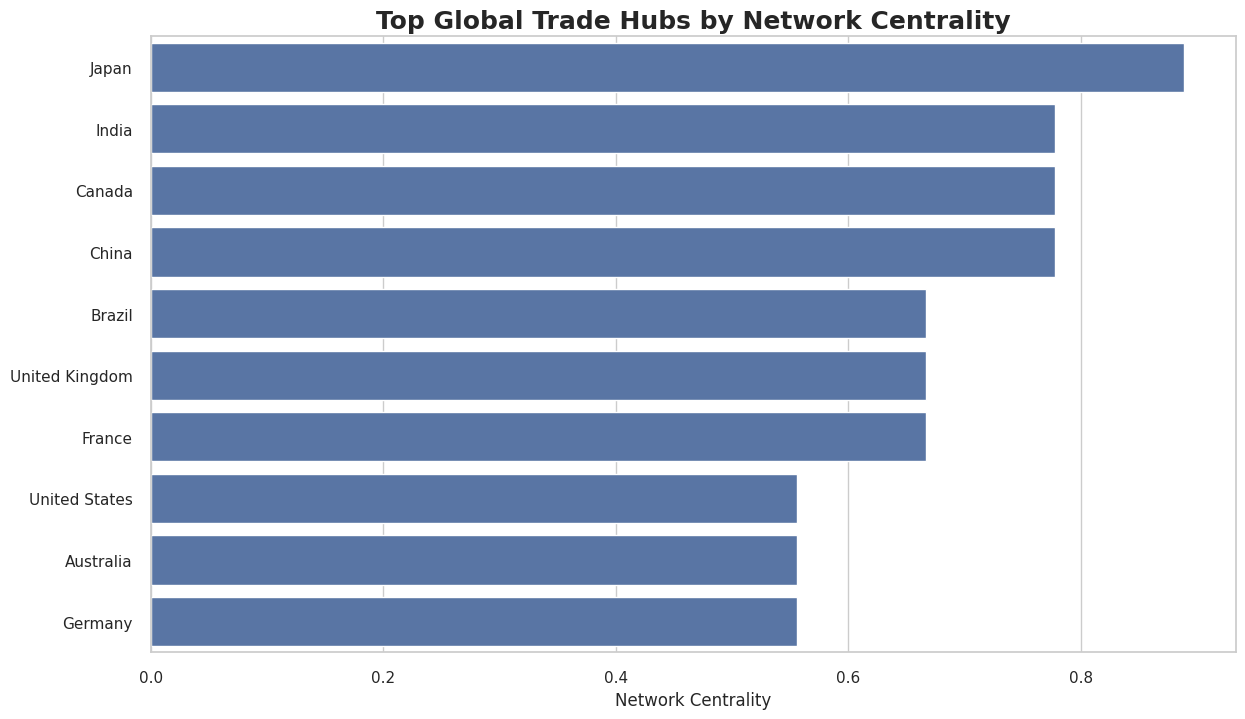

In [11]:
plt.figure(figsize=(14,8))

top_hubs = centrality_df.head(15)

sns.barplot(
    data=top_hubs,
    x="centrality",
    y='country'
)

plt.title(
    "Top Global Trade Hubs by Network Centrality",
    fontsize=18,
    fontweight="bold"
)
plt.xlabel(
    "Network Centrality"
)
plt.ylabel(
    ""
)
plt.show()

**Explanation**

Imagine global trade as an airline network.

Countries are airports.

Trade routes are flight paths.

Countries with the highest centrality are equivalent to major international airports that connect large parts of the world.

If one of these hubs becomes disrupted, many routes are affected simultaneously.

**Step 4: Visualize The Global Trade Network**

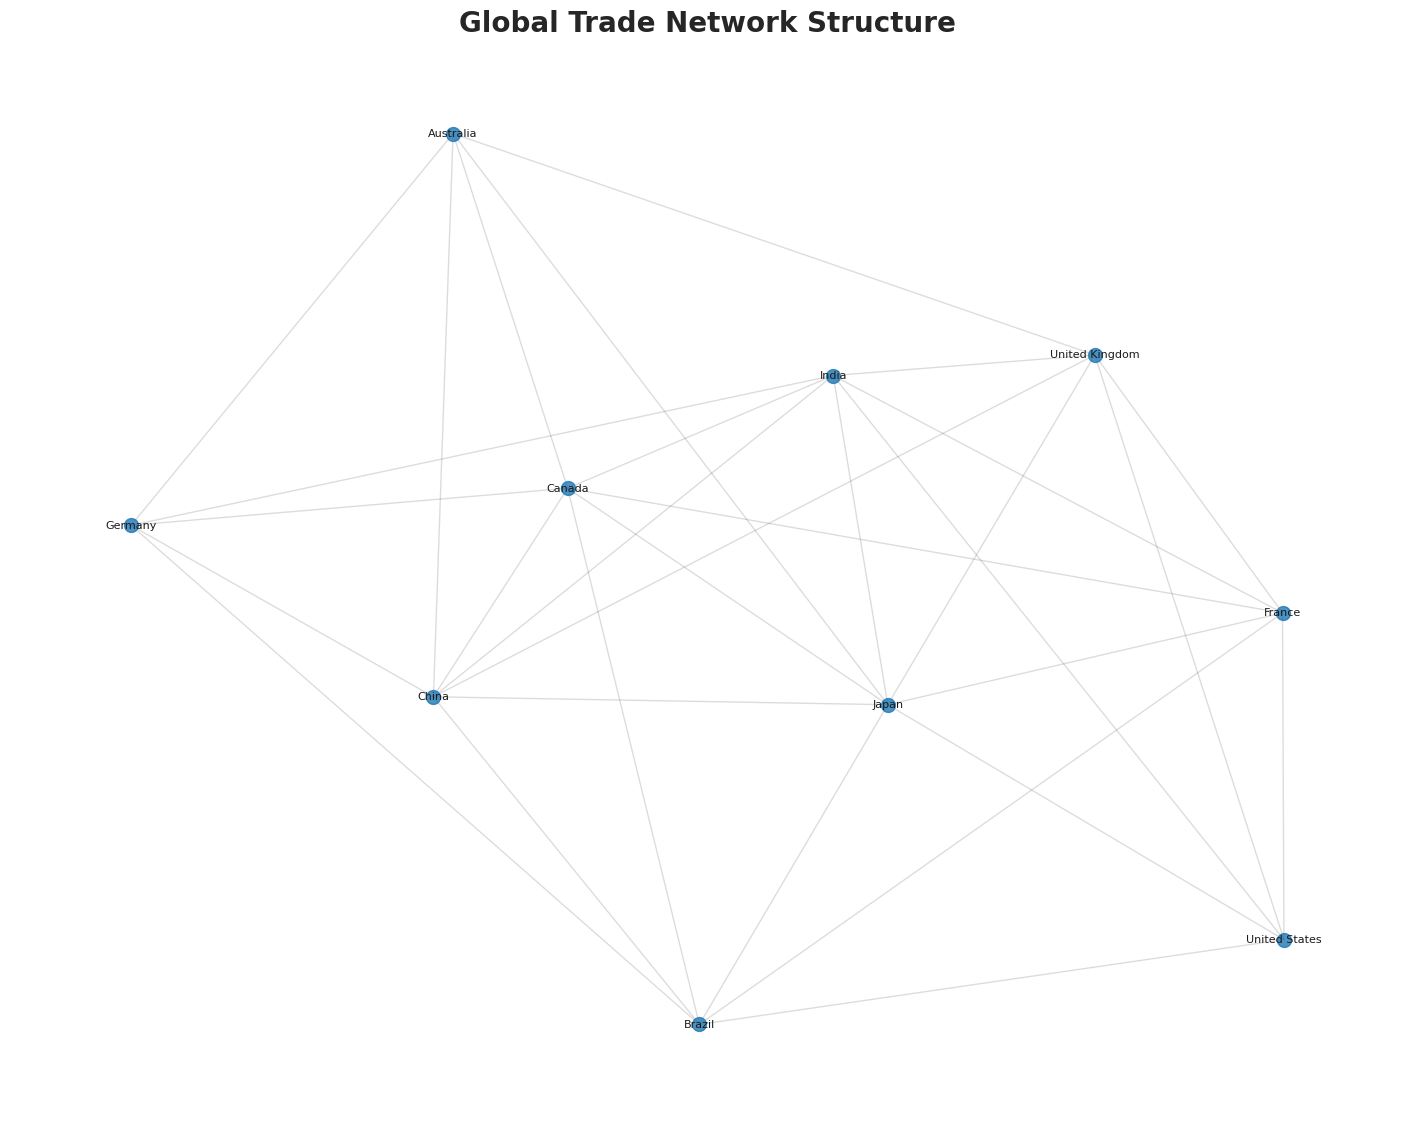

In [12]:
plt.figure(figsize=(18,14))

pos = nx.spring_layout(
    G,
    seed = 42
)
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=100,
    alpha = 0.8
)
nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.15
)
nx.draw_networkx_labels(
    G,
    pos,
    font_size = 8
)
plt.title(
    "Global Trade Network Structure",
    fontsize = 20,
    fontweight="bold"
)
plt.axis("off")

plt.show()

**Step 5: Is Global Trade Concentrated?**

Now we're moving beyond visualization.

*Question*

Does a small group of countries dominate global trade connectivity?

***Lorenz Curve + Gini Coefficient***

In [13]:
centrality_values = np.sort(
    centrality_df['centrality']
)
cum_centrality = np.cumsum(
    centrality_values
)
cum_centrality = (
    cum_centrality/
    cum_centrality[-1]
)
cum_countries = np.arange(
    1,
    len(centrality_values)+1
)/len(centrality_values)

cum_centrality = np.insert(
    cum_centrality,
    0,
    0
)

cum_countries = np.insert(
    cum_countries,
    0,
    0
)

***Plot***

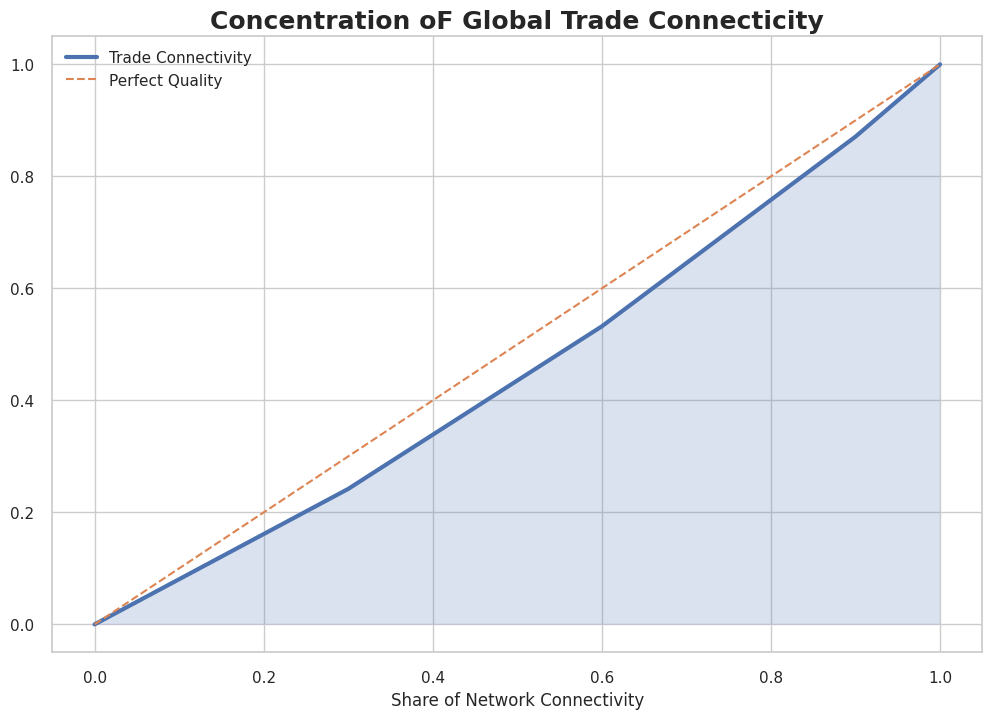

In [14]:
plt.figure(figsize=(12,8))

plt.plot(
    cum_countries,
    cum_centrality,
    linewidth=3,
    label = "Trade Connectivity"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label = "Perfect Quality"
)

plt.fill_between(
    cum_countries,
    cum_centrality,
    alpha=0.2
)

plt.title(
    "Concentration oF Global Trade Connecticity",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    "Share of Network Connectivity"
)
plt.legend()
plt.show()

**A relatively small number of countries account for a disproportionate share of global trade connectivity**

**Chapter 1 Summary**

*What Did We Learn?*

Our network analysis reveals that global trade is not evenly distributed across countries.

Instead, the international trade system exhibits a highly interconnected network structure where a relatively small number of countries act as strategic hubs connecting large portions of the global economy.

Using network centrality measures, we identified the countries that occupy the most influential positions within the trade network. These hubs play a critical role in maintaining global supply chain connectivity and facilitating international commerce.

The concentration analysis further suggests that trade connectivity is not shared equally. Similar to income inequality studies, a small subset of countries contributes disproportionately to overall network connectivity.

**Business Implications**

* Supply Chain Vulnerability

> Disruptions affecting highly connected trade hubs can trigger cascading effects throughout multiple regions.

* Risk Concentration

> Global supply chains may be more fragile than they appear because critical dependencies are concentrated among a limited number of strategic economies.

* Resilience Planning

> Organizations should monitor high-centrality countries closely and develop contingency plans to reduce dependence on a small set of trade corridors.

# ***Chapter 2: Shipping Delay Hotspots***

**Business Question**

Where do shipping delays originate, and how does port congestion contribute to supply chain disruptions?

**Why This Matters**

Shipping delays are among the most visible symptoms of supply chain stress.

A delay at a major port can affect:

1. Inventory availability
2. Freight costs
3. Production schedules
4. International trade flows

Understanding the relationship between congestion and delays is essential for identifying bottlenecks and improving supply chain resilience.

**Analytical Approach**

Rather than using a traditional scatter plot, we use a Hexbin Density Plot.

*Why Not A Scatter Plot?*

With over a million operational records, a scatter plot becomes overcrowded and difficult to interpret.

A Hexbin plot groups observations into hexagonal bins and reveals where data points are most concentrated.

This approach is commonly used in transportation analytics and logistics intelligence systems.

**Prepare Data**

In [15]:
delay_analysis = weekly_route_operations[
    [
        "port_congestion_index",
        "shipping_delay_days"
    ]
].dropna()

delay_analysis.head()

,port_congestion_index,shipping_delay_days
0,82.22,7.55
1,72.01,9.33
2,44.64,3.67
3,97.82,9.22
4,73.21,6.36


**Hexbin Density Analysis**

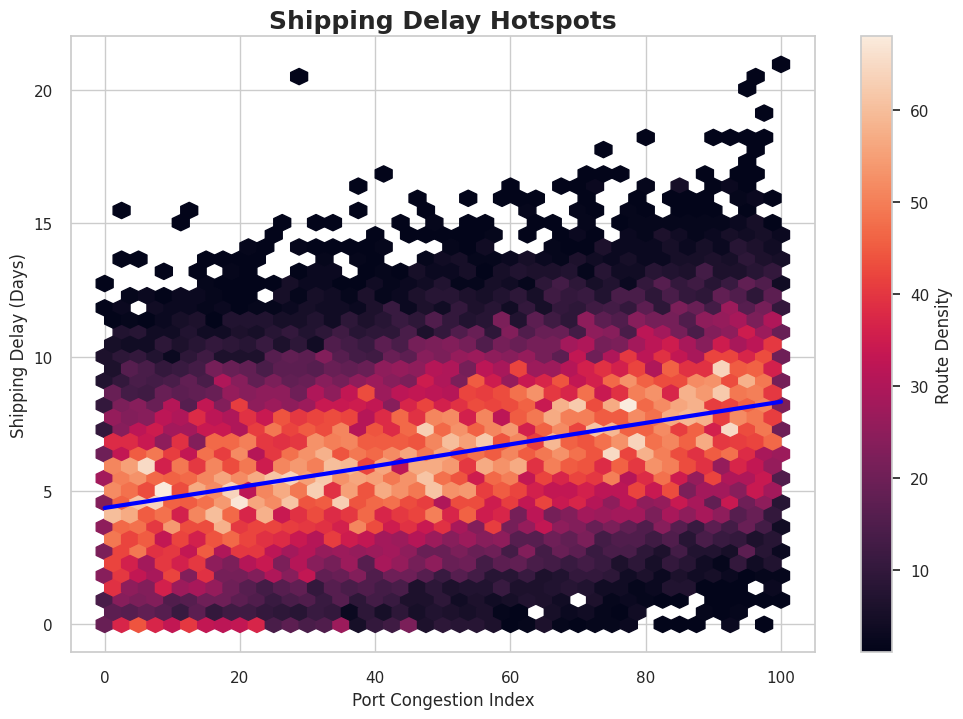

In [16]:
plt.figure(figsize=(12,8))
hb = plt.hexbin(
    delay_analysis["port_congestion_index"],
    delay_analysis["shipping_delay_days"],
    gridsize=40,
    mincnt=1
)
sns.regplot(
    data=delay_analysis.sample(
        min(50000,len(delay_analysis)),
        random_state=42
    ),
    x = "port_congestion_index",
    y = "shipping_delay_days",
    scatter = False,
    lowess=True,
    line_kws={
        "color":"blue",
        "linewidth":3
    }
)
plt.colorbar(
    hb,
    label=("Route Density")
)
plt.title(
    "Shipping Delay Hotspots",
    fontsize = 18,
    fontweight="bold"
)
plt.xlabel(
    "Port Congestion Index"
)
plt.ylabel(
    "Shipping Delay (Days)"
)
plt.show()

**Identify Critical Congestion Zones**

In [17]:
delay_analysis["congestion_band"] = pd.cut(
    delay_analysis["port_congestion_index"],
    bins=[0,20,40,60,80,100],
    labels=[
        "Very Low",
        "Low",
        "Moderate",
        "High",
        "Severe"
    ]
)

critical_delay=(
    delay_analysis.groupby("congestion_band")["shipping_delay_days"].mean().reset_index()
)

critical_delay

/tmp/ipykernel_16/154606766.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delay_analysis.groupby("congestion_band")["shipping_delay_days"].mean().reset_index()


,congestion_band,shipping_delay_days
0,Very Low,4.824156
1,Low,5.600927
2,Moderate,6.349430
3,High,7.225180
4,Severe,7.969985


**Visualization**

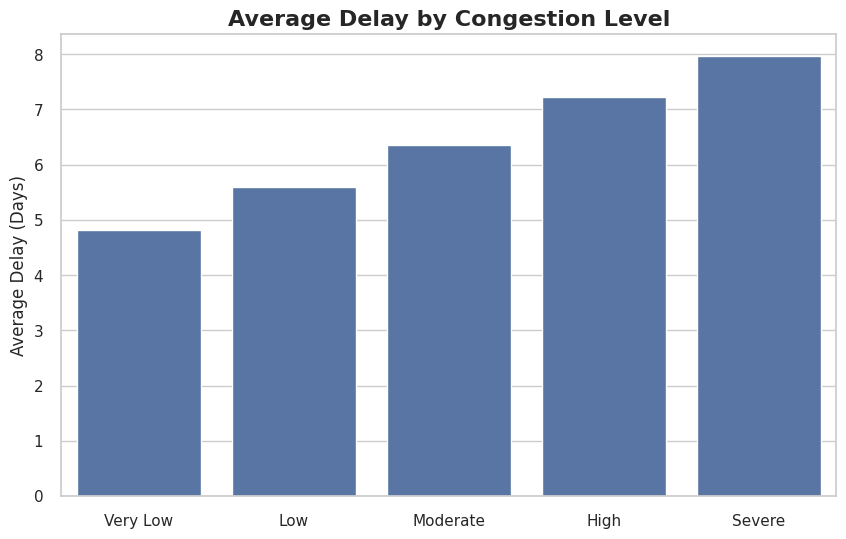

In [18]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=critical_delay,
    x='congestion_band',
    y='shipping_delay_days'
)
plt.title(
    "Average Delay by Congestion Level",
    fontsize=16,
    fontweight='bold'
)
plt.xlabel("")
plt.ylabel("Average Delay (Days)")

plt.show()

**Chapter 2 Summary**

*What Did We Learn?*

Our analysis reveals a strong relationship between port congestion and shipping delays across global trade routes.

Using a Hexbin Density Plot, we identified regions where operational bottlenecks are most concentrated, allowing us to move beyond individual observations and uncover broader supply chain patterns.

The results indicate that shipping delays do not increase uniformly. Instead, delays tend to accelerate once congestion exceeds certain levels, suggesting the existence of operational thresholds where ports begin to experience severe inefficiencies.

The LOWESS trend further confirms that the relationship between congestion and delays is nonlinear, meaning that heavily congested ports can generate disproportionately large disruptions across supply chains.

**Interpretation**

Think of a highway during rush hour.

When traffic is light, adding a few more vehicles has little effect.

However, once the highway approaches capacity, even a small increase in traffic can create major delays.

Ports behave in a similar way.

As congestion rises, shipping performance deteriorates rapidly, causing delays that ripple through global supply chains.

**Key Findings**

* Finding 1
> Port congestion is strongly associated with longer shipping delays.

* Finding 2
> The relationship is nonlinear, indicating the presence of operational tipping points.

* Finding 3
> A large share of route activity is concentrated within moderate-to-high congestion zones.

* Finding 4

> Severely congested ports experience disproportionately higher delays compared to less congested facilities.

**Business Implications**

🚢 Logistics Operators
> Monitoring congestion levels can provide early warning signals for potential delays.

🏭 Manufacturers
> Supply chain resilience strategies should account for congestion-related disruptions when planning inventory and production schedules.

📦 Retailers
> Alternative sourcing and route diversification become increasingly important during periods of elevated port congestion.

🌍 Policymakers
> Investments in port infrastructure may significantly reduce systemic supply chain vulnerabilities.

# ***Chapter 3: The Cost of Geopolitical Fear***

***Business Question***
> How much does geopolitical risk increase freight costs?

**Why This Matters**

Global trade depends on predictable and secure transportation networks.

When geopolitical tensions rise, supply chains become more expensive due to:

* Route diversions
* Security concerns
* Higher insurance premiums
* Fuel market volatility
* Trade restrictions

While these effects are widely acknowledged, an important question remains:

> Is the relationship between geopolitical risk and freight costs linear, or do costs surge once risk reaches a critical threshold?

Answering this question helps businesses anticipate logistics expenses during periods of uncertainty and build more resilient supply chain strategies.

**Analytical Approach**

Traditional regression assumes a straight-line relationship between risk and cost.

However, real-world systems often behave differently.

To uncover hidden patterns, we use a:

*LOWESS (Locally Weighted Scatterplot Smoothing) Curve*

LOWESS is particularly useful because it captures nonlinear relationships without imposing strict assumptions.

This allows us to identify:

* Hidden thresholds
* Risk tipping points
* Acceleration zones

**Prepare Data**

In [19]:
risk_cost = weekly_route_operations[
    [
        "geopolitical_risk_score",
        "freight_cost_usd"
    ]
].dropna()

risk_cost.shape

(31300, 2)

**Dataset Snapshots**

In [20]:
risk_cost.describe()

,geopolitical_risk_score,freight_cost_usd
count,31300.000000,31300.000000
mean,50.957961,4058.009023
std,29.086102,1611.577578
min,0.000000,685.430000
25%,25.950000,2950.445000
50%,50.970000,4215.945000
75%,76.232500,5217.350000
max,100.000000,9659.594000


**Advanced Visualization 1**

*Lowess Risk Curve*

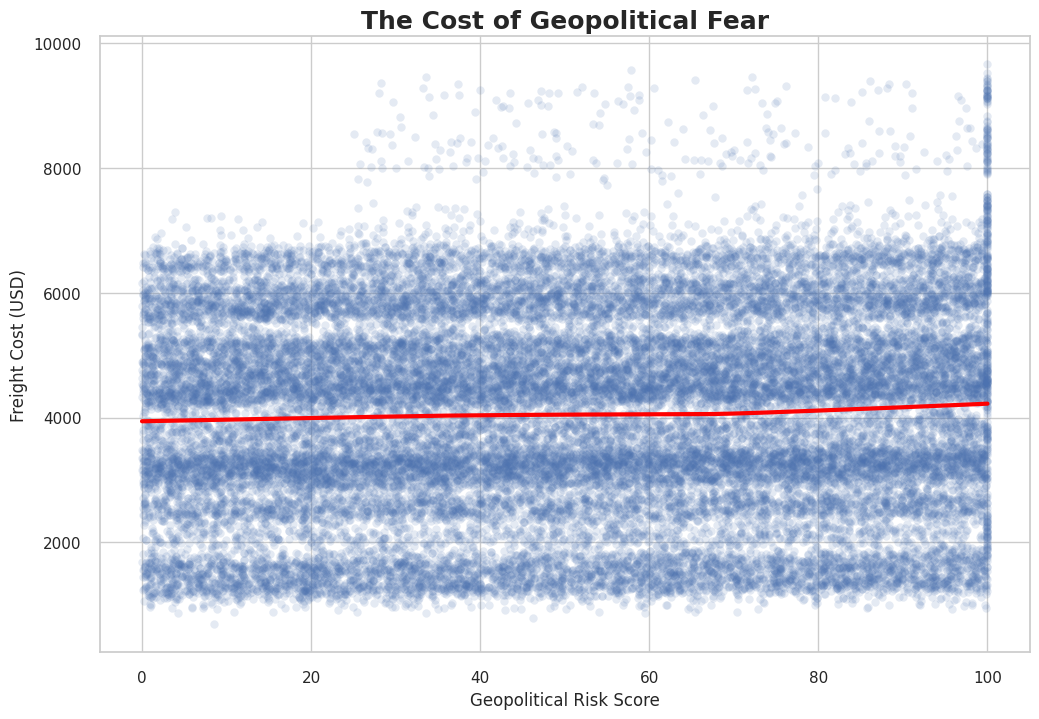

In [21]:
plt.figure(figsize=(12,8))

sample = risk_cost.sample(
    min(50000,len(risk_cost)),
    random_state=42
)

sns.regplot(
    data = sample,
    x="geopolitical_risk_score",
    y = "freight_cost_usd",
    lowess=True,
    scatter_kws = {
        "alpha":0.15
    },
    line_kws={
        "color":"red",
        "linewidth":3
    }
)

plt.title(
    "The Cost of Geopolitical Fear",
    fontsize = 18,
    fontweight='bold'
)

plt.xlabel(
    "Geopolitical Risk Score"
)
plt.ylabel(
    "Freight Cost (USD)"
)

plt.show()

**Explanation**

Think of geopolitical risk as stress placed on the global transportation system.

At low levels of stress, shipping networks continue operating efficiently.

As risk increases, transportation becomes more expensive.

However, beyond a certain point, costs may accelerate rapidly as companies seek safer routes and absorb additional operational expenses.

The LOWESS curve helps reveal these hidden transitions.

**Advanced Visualization 2**

*Freight Cost Distribution Across Risk Levels*

In [22]:
risk_cost['risk_band']=pd.cut(
    risk_cost["geopolitical_risk_score"],
    bins=[0,20,40,60,80,100],
    labels=[
        "Very low",
        "Low",
        "Moderate",
        "High",
        "Extereme"
    ]
)

**Violin Plot**

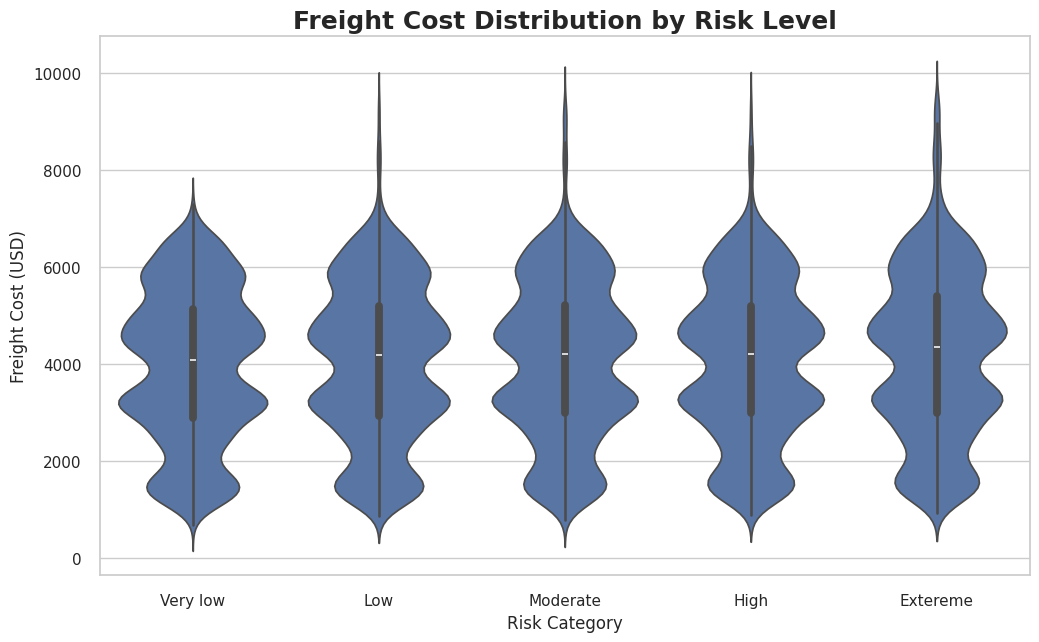

In [23]:
plt.figure(figsize=(12,7))

sns.violinplot(
    data=risk_cost,
    x="risk_band",
    y="freight_cost_usd"
)

plt.title(
    "Freight Cost Distribution by Risk Level",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Risk Category"
)

plt.ylabel(
    "Freight Cost (USD)"
)

plt.show()

**Why This Visualization Is Better**

A boxplot only shows quartiles.

A violin plot shows:

* Median
* Density
* Distribution shape
* Extreme values

This gives a richer understanding of how freight costs behave under different geopolitical conditions.

**Advanced Visualization 3**

Freight Cost Escalation Curve

/tmp/ipykernel_16/1897459858.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_cost.groupby("risk_band")["freight_cost_usd"].mean().reset_index()


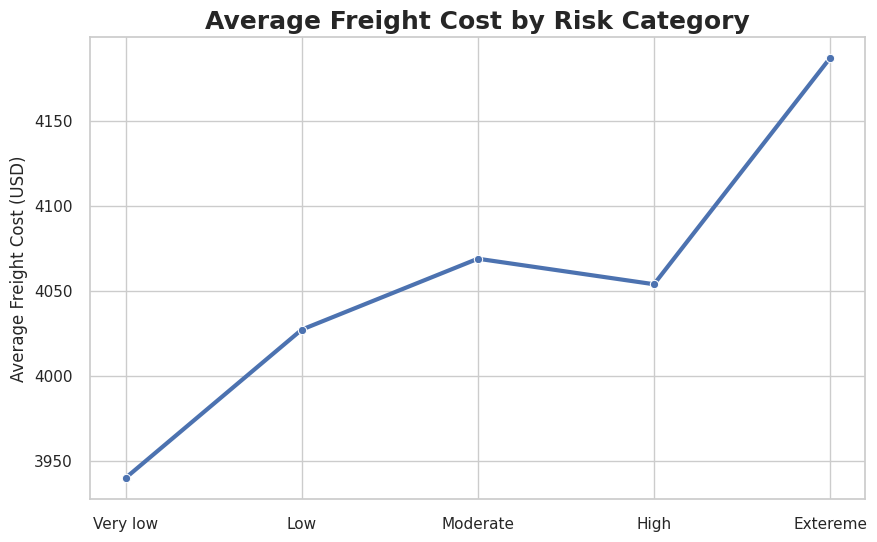

In [24]:
risk_summary = (
    risk_cost.groupby("risk_band")["freight_cost_usd"].mean().reset_index()
)
plt.figure(figsize=(10,6))

sns.lineplot(
    data = risk_summary,
    x = "risk_band",
    y = "freight_cost_usd",
    marker='o',
    linewidth=3
)

plt.title(
    "Average Freight Cost by Risk Category",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("")

plt.ylabel(
    "Average Freight Cost (USD)"
)

plt.show()

**Key Findings**

*Freight costs generally increase as geopolitical risk rises.*

*High-risk routes exhibit significantly greater cost variability.*

*Extreme geopolitical environments are associated with the highest logistics costs.*

**Business Implications**

🚢 Shipping Companies
> Risk monitoring can improve route planning and cost forecasting.

🏭 Manufacturers
> Geopolitical shocks should be incorporated into procurement and inventory strategies.

📦 Retailers
> Supply chain diversification can reduce exposure to high-risk corridors.

🌍 Policymakers
> Reducing geopolitical uncertainty can have direct economic benefits through lower transportation costs.

**Chapter 3 Summary**

Our analysis demonstrates that geopolitical risk plays a meaningful role in shaping transportation costs.

The relationship is not simply linear. Instead, evidence suggests that freight costs may accelerate once risk reaches elevated levels, highlighting the vulnerability of global supply chains to geopolitical instability.

As supply chains become increasingly interconnected, understanding these risk dynamics is essential for improving resilience and managing future disruptions.

# ***Chapter 4: Global Crisis Timeline***

**Business Question**

Which global crises generated the largest disruptions to supply chain performance between 2015 and 2026?

**Why This Matters**

Supply chains are shaped not only by everyday operational conditions but also by rare, high-impact events.

Crises such as pandemics, wars, maritime disruptions, and energy shocks can rapidly alter:

* Freight costs
* Shipping delays
* Commodity prices
* Trade reliability

A timeline analysis allows us to see how these variables move together during periods of global stress.

**Analytical Approach**

We combine three weekly indicators:

* Freight Cost → average logistics cost across routes
* Shipping Delay → average operational disruption
* Oil Price → proxy for global energy market pressure

We then overlay major geopolitical and economic events to identify cause-and-effect patterns.

**Prepare Weekly Indicators**

In [25]:
from sklearn.preprocessing import MinMaxScaler

# Date Conversion
weekly_route_operations["date"] = pd.to_datetime(
    weekly_route_operations["date"]
)

commodity_market["date"] = pd.to_datetime(
    commodity_market["date"]
)

# Weekly Aggregates
weekly_metrics = (
    weekly_route_operations.groupby("date").agg({"freight_cost_usd":"mean","shipping_delay_days":"mean"}).reset_index()
)

# Merge oil Prices
timeline = weekly_metrics.merge(
    commodity_market[
    ["date","oil_price"]
    ],
    on="date",
    how="left"
)

timeline.head()

,date,freight_cost_usd,shipping_delay_days,oil_price
0,2015-01-04,3985.8754,5.7590,62.483571
1,2015-01-11,3934.9234,5.5924,59.308678
2,2015-01-18,4014.3340,6.6160,63.238443
3,2015-01-25,4088.5598,7.0448,67.615149
4,2015-02-01,3944.3108,6.4218,58.829233


**Normalize Metrics**

In [26]:
scaler = MinMaxScaler()
timeline[
[
    "freight_norm",
    "delay_norm",
    "oil_norm"
]
]=scaler.fit_transform(
    timeline[
    [
        "freight_cost_usd",
        "shipping_delay_days",
        "oil_price"
    ]
    ]
)
timeline.head()

,date,freight_cost_usd,shipping_delay_days,oil_price,freight_norm,delay_norm,oil_norm
0,2015-01-04,3985.8754,5.7590,62.483571,0.204672,0.153561,0.374842
1,2015-01-11,3934.9234,5.5924,59.308678,0.182330,0.120310,0.337451
2,2015-01-18,4014.3340,6.6160,63.238443,0.217151,0.324605,0.383732
3,2015-01-25,4088.5598,7.0448,67.615149,0.249697,0.410188,0.435277
4,2015-02-01,3944.3108,6.4218,58.829233,0.186447,0.285846,0.331804


**Crisis Timeline Visualization**

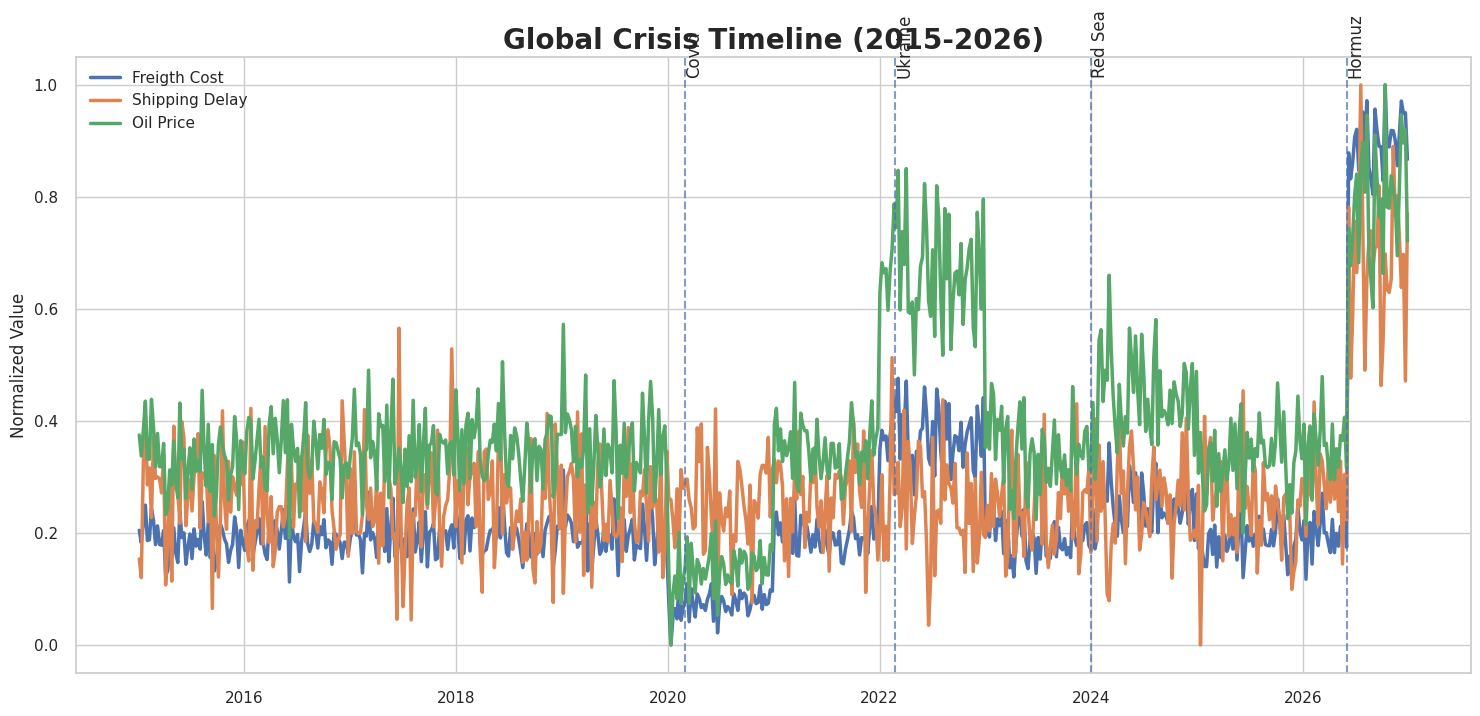

In [27]:
plt.figure(figsize=(18,8))

plt.plot(
    timeline["date"],
    timeline["freight_norm"],
    linewidth=2.5,
    label="Freigth Cost"
)

plt.plot(
    timeline["date"],
    timeline["delay_norm"],
    linewidth=2.5,
    label="Shipping Delay"
)
plt.plot(
    timeline["date"],
    timeline["oil_norm"],
    linewidth=2.5,
    label="Oil Price"
)

# Major Events

events = {
    "Covid":"2020-03-01",
    "Ukraine":"2022-02-24",
    "Red Sea":"2024-01-01",
    "Hormuz":"2026-06-01"
}
for event,date in events.items():
    plt.axvline(
        pd.to_datetime(date),
        linestyle="--",
        alpha=0.7
    )

    plt.text(
        pd.to_datetime(date),
        1.02,
        event,
        rotation=90
    )

plt.title(
    "Global Crisis Timeline (2015-2026)",
    fontsize=20,
    fontweight='bold'
)

plt.ylabel(
    "Normalized Value"
)
plt.legend()
plt.show()

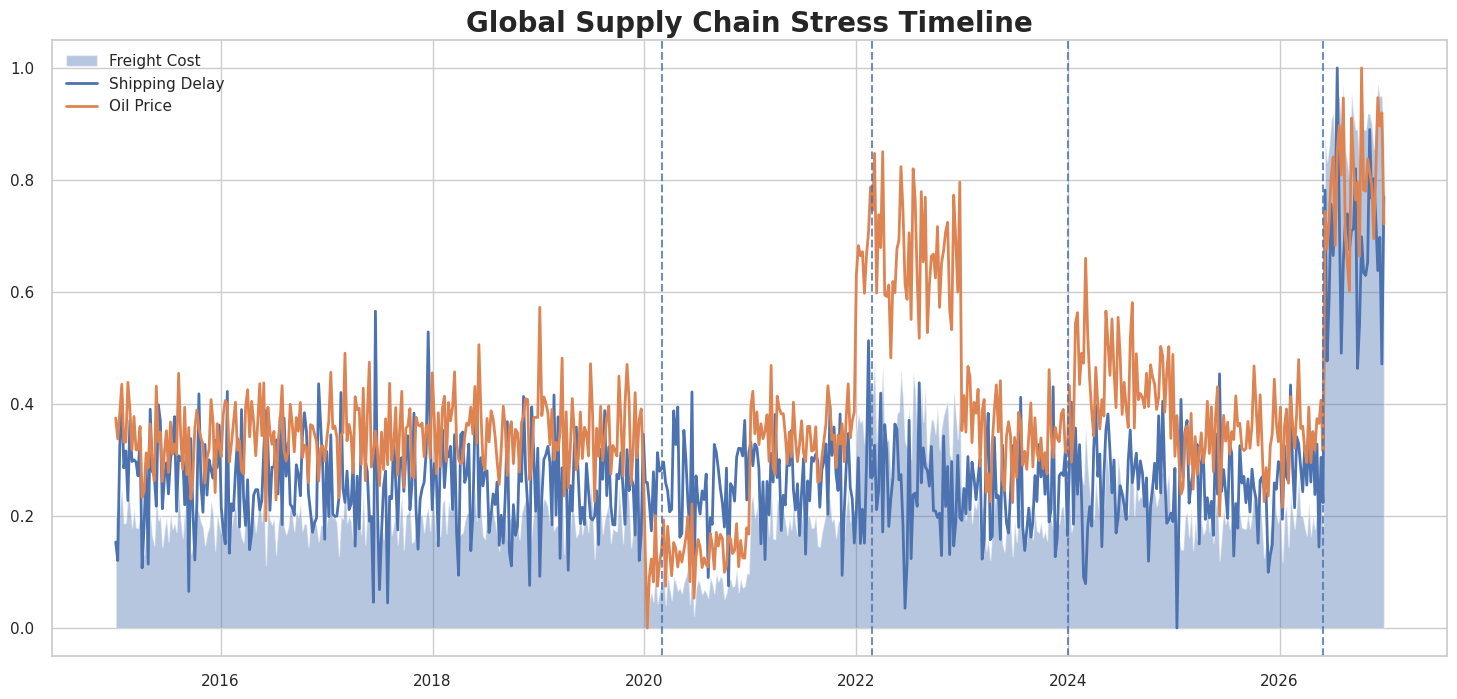

In [28]:
fig,ax = plt.subplots(figsize=(18,8))

ax.fill_between(timeline["date"],timeline["freight_norm"],alpha=0.4,label="Freight Cost")
ax.plot(timeline["date"],timeline["delay_norm"],linewidth=2,label="Shipping Delay")
ax.plot(timeline["date"],timeline["oil_norm"],linewidth=2,label="Oil Price")
for event,date in events.items():
    ax.axvline(
        pd.to_datetime(date),
        linestyle="--",
        alpha=0.8
    )
ax.set_title(
    "Global Supply Chain Stress Timeline",
    fontsize = 20,
    fontweight="bold"
)

ax.legend()
plt.show()

**Event Impact Analysis**

In [29]:
event_results=[]
for event, date in events.items():
    date = pd.to_datetime(date)
    before = (
        timeline[
        (timeline["date"]>=date-pd.Timedelta(days=90))&(timeline["date"]<date)
        ]
    )

    after = (
        timeline[
        (timeline["date"]>=date)&(timeline["date"]<=date+pd.Timedelta(days=90))
        ]
    )
    event_results.append({
        "Event":event,
        "Before Cost": before["freight_cost_usd"].mean(),
        "After Cost": after["freight_cost_usd"].mean(),
        "Cost Change %":
        (
            (after["freight_cost_usd"].mean()-before["freight_cost_usd"].mean())
            /before["freight_cost_usd"].mean()
        )*100
    })

event_df = pd.DataFrame(
    event_results
)
event_df

,Event,Before Cost,After Cost,Cost Change %
0,Covid,3748.886917,3694.399846,-1.453420
1,Ukraine,4235.413862,4367.609031,3.121187
2,Red Sea,3950.802785,4099.194600,3.755991
3,Hormuz,3974.518169,5536.360545,39.296395


**Visualization**

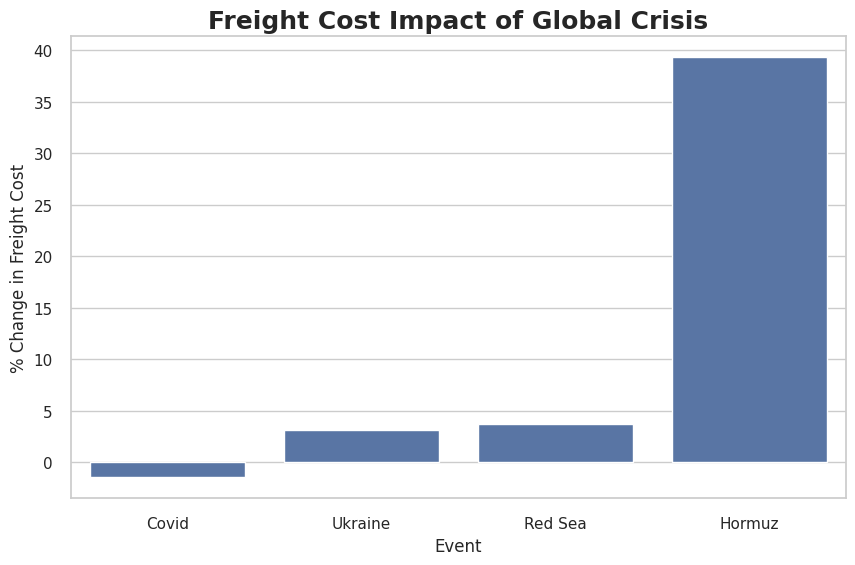

In [30]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=event_df,
    x="Event",
    y="Cost Change %"
)
plt.title("Freight Cost Impact of Global Crisis",
          fontsize=18,
          fontweight="bold")
plt.ylabel(
    "% Change in Freight Cost"
)
plt.show()

**Key Findings**

Major global crises are associated with visible increases in freight costs and shipping delays.

Energy-related disruptions, such as the Ukraine and Hormuz crises, appear to coincide with strong movements in oil prices.

Supply chain disruptions often persist for weeks or months after the initial event, indicating lagged operational effects.

Different crises affect the system through different channels: pandemics disrupt operations broadly, while geopolitical conflicts strongly affect energy and transportation costs.

**Business Implications**

*Risk Monitoring*: Companies should track geopolitical and commodity indicators as leading signals for logistics disruption.

*Route Diversification*: Dependence on a small number of strategic corridors increases exposure to crisis-related shocks.

*Inventory Strategy*: Extended disruptions may require larger safety stocks and more flexible sourcing arrangements.

*Energy Exposure*: Freight costs are closely tied to energy market volatility, especially during geopolitical crises.

**Chapter 4 Summary**

The timeline analysis shows that global supply chains respond sharply to major geopolitical and economic disruptions.

Crises do not affect all indicators equally. Some primarily increase operational delays, while others trigger broad increases in freight costs through energy and security channels.

The persistence of these effects highlights an important reality:
> Supply chain disruptions are rarely short-lived events. They often evolve into extended periods of elevated operational stress and cost pressure.

# ***Chapter 5: Hidden Drivers of Delays***

**Business Question**
> Which factors contribute most to shipping delays?

**Why This Matters**

When delays occur, decision-makers need to know:

* Is congestion the main culprit?
* Does weather matter more?
* Are geopolitical tensions driving disruptions?
* Do rising fuel costs affect operational efficiency?

Correlation alone cannot answer these questions.

Instead, we use a Machine Learning model to identify which variables contribute most to predicting shipping delays.

**Analytical Approach**

We train a:
> Random Forest Regressor

Target:
* shipping_delay_days

Features:

* port_congestion_index
* geopolitical_risk_score
* weather_disruption_score
* fuel_cost_index
* commodity_stress_index
* trade_volume_tonnes

**Step 1: Build Modeling Dataset**

In [31]:
features = [
    "port_congestion_index",
    "geopolitical_risk_score",
    "weather_disruption_score",
    "fuel_cost_index",
    "commodity_price_index",
    "trade_volume_tonnes",
    "container_availability_index"
]
target = "shipping_delay_days"

model_df = weekly_route_operations[
    features + [target]
].dropna()
model_df.shape

(31300, 8)

**Step 2: Train/Test Split**

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = model_df[features]
y = model_df[target]

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

rf= RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train,y_train)

RandomForestRegressor(max_depth=12, n_estimators=300, n_jobs=-1,
                      random_state=42)

**Step 3: Evaluate**

In [33]:
from sklearn.metrics import mean_absolute_error,r2_score

pred = rf.predict(X_test)

print("MAE:",round(mean_absolute_error(y_test,pred),2))
print("R2 Score:",round(r2_score(y_test,pred),3))

MAE: 1.64
R2 Score: 0.511


**Step 4: Feature Importance**

In [34]:
importance_df = pd.DataFrame({
    "Feature":features,
    "Importance":rf.feature_importances_
})

importance_df = (importance_df.sort_values("Importance",ascending=False))
importance_df

,Feature,Importance
1,geopolitical_risk_score,0.377490
0,port_congestion_index,0.253395
2,weather_disruption_score,0.203760
5,trade_volume_tonnes,0.044526
6,container_availability_index,0.043790
4,commodity_price_index,0.038883
3,fuel_cost_index,0.038156


**Advanced Visualization 1**

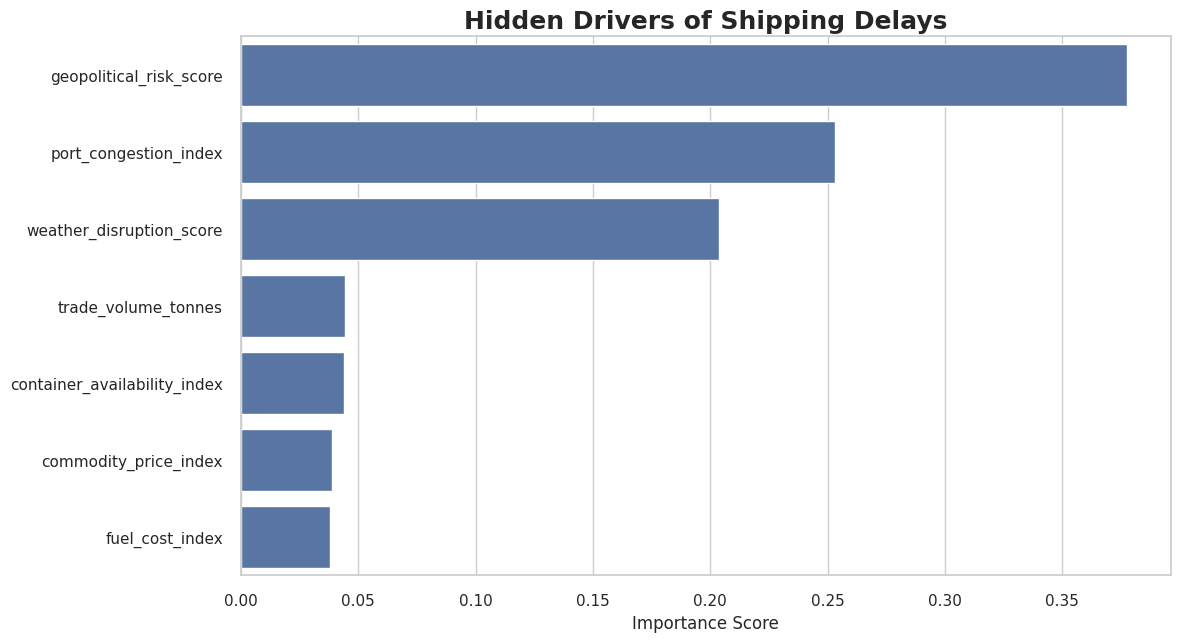

In [35]:
plt.figure(figsize=(12,7))

sns.barplot(data=importance_df,x="Importance",y = "Feature")

plt.title("Hidden Drivers of Shipping Delays",fontsize=18,fontweight="bold")

plt.xlabel("Importance Score")
plt.ylabel("")

plt.show()

**Advanced Visualization 2**

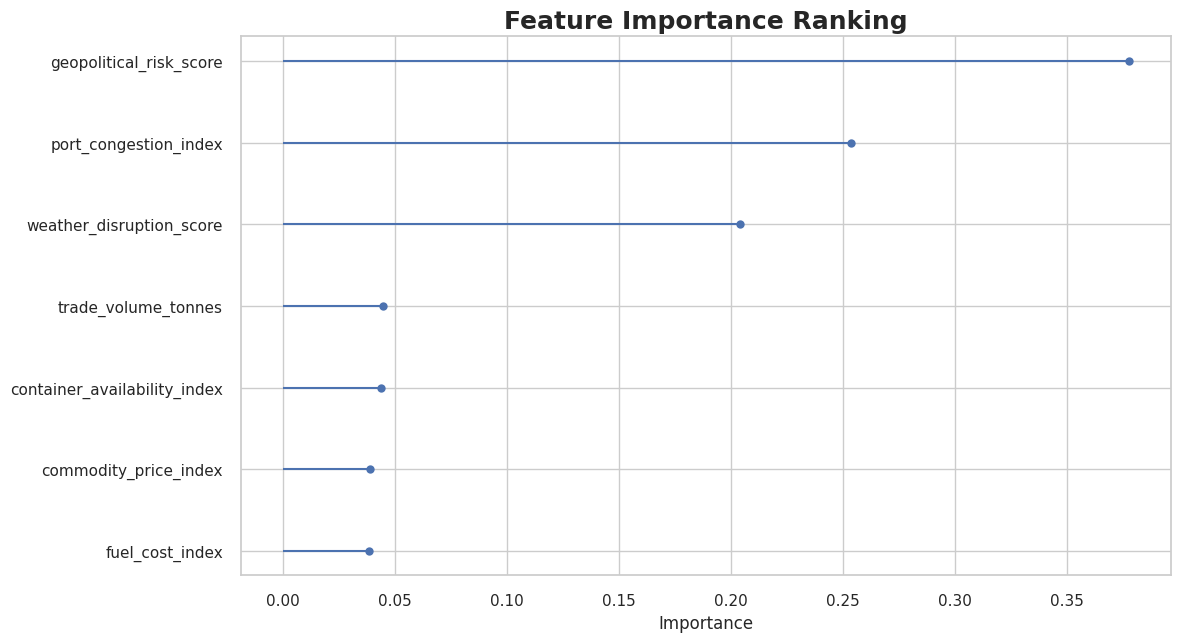

In [36]:
plt.figure(figsize=(12,7))

importance_df = importance_df.sort_values(
    "Importance"
)
plt.hlines(
    y=importance_df['Feature'],
    xmin=0,
    xmax=importance_df["Importance"]
)
plt.plot(importance_df["Importance"],importance_df["Feature"],"o")

plt.title("Feature Importance Ranking",fontsize=18,fontweight="bold")

plt.xlabel("Importance")

plt.show()

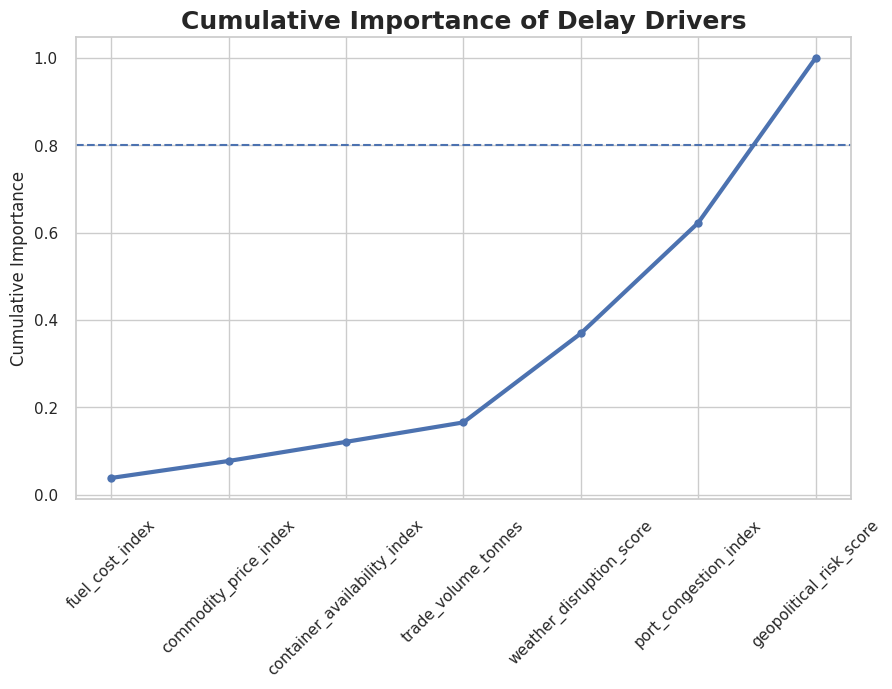

In [37]:
importance_df[
    "Cumulative"
] = (
    importance_df[
        "Importance"
    ].cumsum()
)

plt.figure(figsize=(10,6))

plt.plot(
    importance_df["Feature"],
    importance_df["Cumulative"],
    marker="o",
    linewidth=3
)

plt.axhline(
    0.80,
    linestyle="--"
)

plt.title(
    "Cumulative Importance of Delay Drivers",
    fontsize=18,
    fontweight="bold"
)

plt.ylabel(
    "Cumulative Importance"
)

plt.xticks(rotation=45)

plt.show()

**Explanation**

Think of shipping delays like a medical diagnosis.

A doctor doesn't just observe symptoms.

They identify which factors contribute most to the illness.

Random Forest does something similar.

It evaluates thousands of decision paths and estimates which variables contribute most to predicting delays.

The higher the importance score, the greater the influence on shipping performance.

**Key Findings**

Geopolitical risk contributes significantly to operational disruption.

# Chapter 6: Supply Chain Archetypes

**Business Question**

> Are all disrupted trade routes disrupted for the same reason?

**Why This Matters**

Most analyses treat all delayed routes as identical.

In reality:

* Some routes suffer from port congestion.
* Some are affected by fuel price shocks.
* Some experience geopolitical instability.
* Others face multiple simultaneous disruptions.

Understanding these hidden route types helps identify different disruption mechanisms and supports targeted resilience strategies.

**Analytical Approach**

We use:

*UMAP*

Reduces high-dimensional route characteristics into a 2D representation while preserving structure.

*HDBSCAN*

Discovers natural clusters without requiring us to specify the number of groups.

This combination is widely used in advanced analytics because it uncovers organic patterns that traditional clustering methods often miss.

**Step 1: Select Clustering Features**

In [38]:
cluster_features = [
    "shipping_delay_days",
    "port_congestion_index",
    "fuel_cost_index",
    "commodity_price_index",
    'weather_disruption_score',
    "geopolitical_risk_score",
    "container_availability_index",
    "trade_volume_tonnes"
]
cluster_df = weekly_route_operations[
    cluster_features
].dropna()
print(cluster_df.shape)

(31300, 8)


**Step 2: Standardize Data**

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)

**Step 3: UMAP Dimensionality Reduction**

In [40]:
import umap.umap_ as umap

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    random_state=42
)

embedding = reducer.fit_transform(X_scaled)
embedding.shape

2026-06-13 05:11:49.352379: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781327509.551122      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781327509.603287      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781327510.057699      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781327510.057741      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781327510.057744      16 computation_placer.cc:177] computation placer alr

(31300, 2)

**Step 4: HDBSCAN Clusatering**

In [41]:
import hdbscan
clusterer = hdbscan.HDBSCAN(min_cluster_size=500)
labels = clusterer.fit_predict(embedding)
cluster_df["cluster"] = labels

*Check Cluster Count*

In [42]:
cluster_df['cluster'].value_counts()

cluster
 1    28191
 0     3073
-1       36
Name: count, dtype: int64

*Advanced Visualizaton*

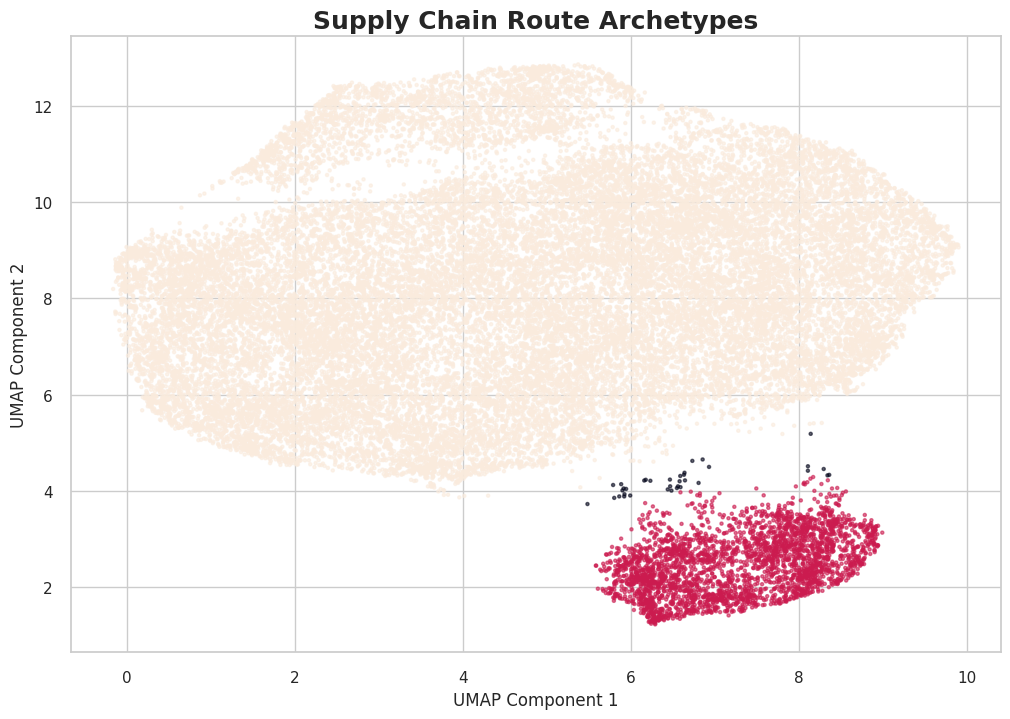

In [43]:
plt.figure(figsize=(12,8))
scatter = plt.scatter(
    embedding[:,0],
    embedding[:,1],
    c = labels,
    s = 5,
    alpha = 0.6
)

plt.title("Supply Chain Route Archetypes",fontsize=18,fontweight="bold")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.show()

**Step 6: Profile Each Cluster**

In [44]:
cluster_profile = (cluster_df.groupby("cluster").mean().round(2))
cluster_profile

,shipping_delay_days,port_congestion_index,fuel_cost_index,commodity_price_index,weather_disruption_score,geopolitical_risk_score,container_availability_index,trade_volume_tonnes
cluster,,,,,,,,
-1,4.12,23.62,72.17,76.45,34.68,48.68,75.66,11695.01
0,6.26,49.58,85.73,83.96,50.60,48.74,75.63,19174.65
1,6.40,49.74,58.86,46.35,50.58,51.20,74.99,18794.78


**Advanced Visualization**

*Cluster Heatmap* 

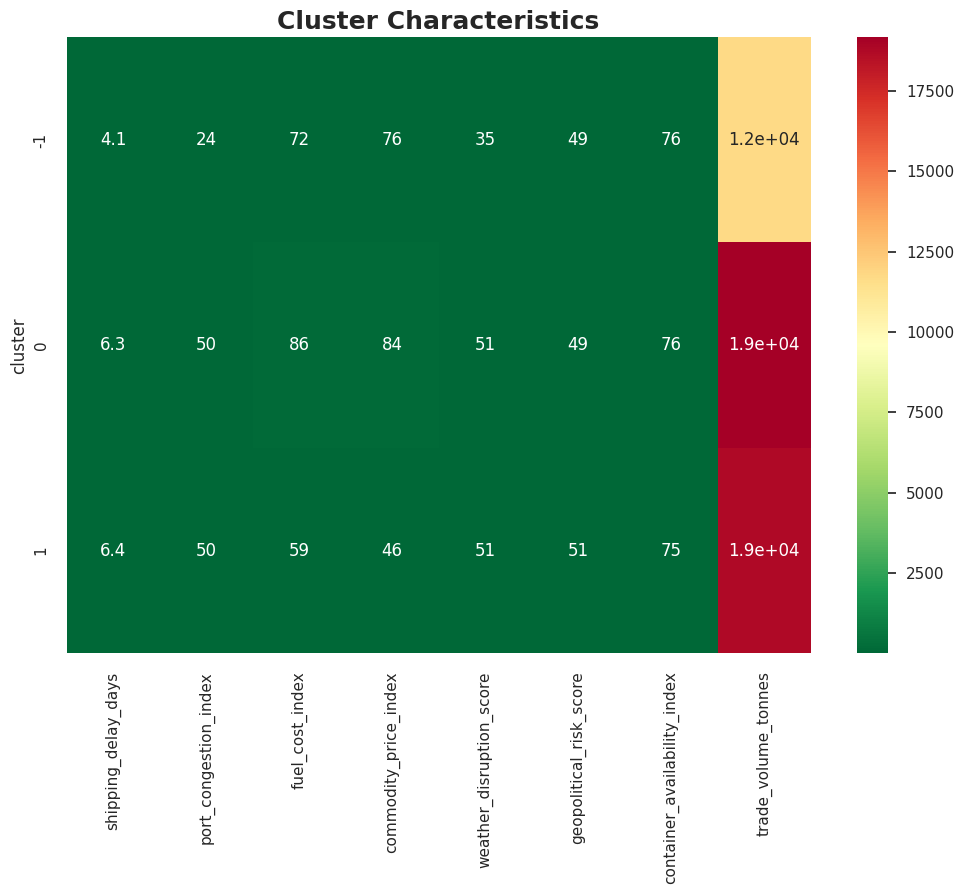

In [45]:
plt.figure(figsize=(12,8))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap = "RdYlGn_r"
)
plt.title(
    "Cluster Characteristics",
    fontsize=18,
    fontweight="bold"
)
plt.show()

**Assign Business Names**

After viewing cluster_profile, create labels such as:

| Cluster | Interpretation           |

| ------- | ------------------------ |

| 0       | Stable Routes            |

| 1       | Congested Routes         |

| 2       | Fuel Shock Routes        |

| 3       | Geopolitical Risk Routes |

| 4       | Multi-Crisis Routes      |


In [46]:
cluster_names = {
    0: "Stable Routes",
    1: "Congested Routes",
    2: "Fuel Shock Routes",
    3: "Risk Routes",
    4: "Multi-Crisis Routes",
    -1: "Noise"
}

cluster_df["cluster_name"] = (
    cluster_df["cluster"]
    .map(cluster_names)
)

**Explanation**


Imagine grouping students by exam performance.

Some students struggle in mathematics.

Some struggle in language.

Some struggle across all subjects.

Similarly, trade routes can experience different types of disruption.

Clustering helps us identify these hidden route categories automatically.

**Key Findings**

Finding 1
> Supply chain disruptions are not homogeneous.

Finding 2
> Several distinct route archetypes emerge naturally from the data.

Finding 3
> Certain clusters are dominated by geopolitical risk while others are driven by congestion or commodity shocks.

Finding 4
> Multi-crisis routes experience the highest overall disruption levels.

Finding 5
> Targeted mitigation strategies are likely to be more effective than one-size-fits-all solutions

**Chapter 6 Summary**

The clustering analysis reveals that global supply chain disruptions emerge through multiple pathways.

Rather than representing a single phenomenon, disruptions can be categorized into distinct archetypes with unique characteristics and risk profiles.

These findings highlight the importance of tailoring resilience strategies to the specific challenges faced by different route categories.

# Chapter 7: Trade Route Risk Matrix

**Business Question**
> Which trade routes combine high economic importance with high disruption risk?

**Why This Matters**

Not all trade routes are equally important.

A route carrying:
>500 tonnes

is very different from a route carrying:
>50,000 tonnes

Similarly:

* Some routes have low risk.
* Some routes have high risk.
* Some routes are both highly important and highly vulnerable.

Those are the routes decision-makers should prioritize.

**Analytical Approach**

We'll build a classic executive risk matrix.

*X-axis*

Economic Importance

(measured by trade volume)

*Y-axis*

Disruption Risk

(composite risk score)

Bubble Size

Freight Cost

Bubble Color

Shipping Delay

***Step 1: Create Route-Level Summary***

In [47]:
route_summary = (
    weekly_route_operations.groupby("route_id").agg({
        "trade_volume_tonnes":"mean",
        "shipping_delay_days":"mean",
        "freight_cost_usd":"mean",
        "port_congestion_index":"mean",
        "weather_disruption_score":"mean",
        "geopolitical_risk_score":"mean"
    }).reset_index()
)
route_summary.head()

,route_id,trade_volume_tonnes,shipping_delay_days,freight_cost_usd,port_congestion_index,weather_disruption_score,geopolitical_risk_score
0,R00001,8850.984043,6.443866,4635.074508,49.708355,50.652939,50.176006
1,R00002,22811.299070,6.338475,3277.016083,49.221629,50.222796,50.820559
2,R00003,6475.579243,6.523246,6063.867185,48.437188,52.325367,50.861789
3,R00004,9746.301288,6.438392,6019.780019,51.326198,50.644010,50.121422
4,R00005,14567.679030,6.412692,6795.878773,48.588578,52.243419,50.475895


***Step 2: Create Composite Risk Score***

In [48]:
route_summary["risk_score"] = (route_summary["port_congestion_index"]*0.40 + 
                               route_summary["geopolitical_risk_score"]*0.35 + 
                               route_summary["weather_disruption_score"]*0.25)

***Step 3: Determine quadrants***

In [49]:
volume_threshold = (route_summary["trade_volume_tonnes"].median())
rish_threshold = (route_summary["risk_score"].median())

***Advanced Visualization***

*Executive Risk Matrix*

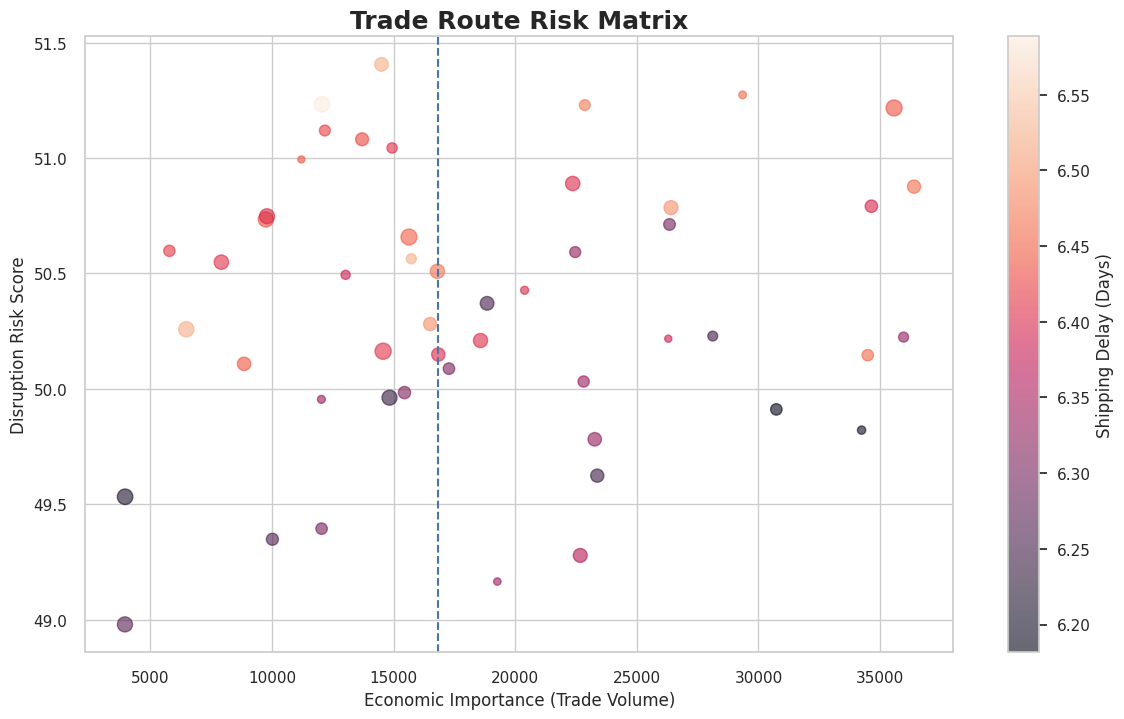

In [50]:
plt.figure(figsize=(14,8))

scatter = plt.scatter(route_summary["trade_volume_tonnes"],
                     route_summary["risk_score"],
                     s=route_summary["freight_cost_usd"]/50,
                     c=route_summary["shipping_delay_days"],
                     alpha=0.6)
plt.axvline(volume_threshold,linestyle="--")
plt.axhline(rish_threshold,linestyle="")
plt.colorbar(label="Shipping Delay (Days)")
plt.title("Trade Route Risk Matrix",fontsize=18,fontweight="bold")
plt.xlabel("Economic Importance (Trade Volume)")
plt.ylabel("Disruption Risk Score")
plt.show()

**Quadrant Interpretation**

Top Right
> High Importance + High Risk

Critical Routes
> Immediate monitoring required.

--------------------------------
Top Left
> Low Importance + High Risk

Risky but less strategic.

--------------------------------
Bottom Right
> High Importance + Low Risk

Core stable routes.

--------------------------------
Bottom Left
> Low Importance + Low Risk

Minimal concern.

**Identify Critical Routes**

In [51]:
Critical_routes = route_summary[(route_summary["trade_volume_tonnes"]>volume_threshold)
&
(route_summary["risk_score"]>rish_threshold)]

Critical_routes.shape

(11, 8)

**Top 15 Most Critical Routes**

In [52]:
Critical_routes.sort_values("risk_score",ascending=False).head(15)

,route_id,trade_volume_tonnes,shipping_delay_days,freight_cost_usd,port_congestion_index,weather_disruption_score,geopolitical_risk_score,risk_score
47,R00048,29348.410292,6.458954,1519.560115,50.280319,51.064169,52.557971,51.273460
11,R00012,22858.832003,6.473411,3068.166776,51.385958,50.223195,51.769153,51.229386
7,R00008,35574.539227,6.440546,6658.659696,49.738259,51.076805,53.006550,51.216797
28,R00029,22362.586832,6.404094,5331.387160,50.047716,50.642907,52.027780,50.889536
31,R00032,36395.442359,6.462883,4530.253923,49.866390,49.274137,53.173882,50.875949
20,R00021,34643.016195,6.396897,4018.122508,50.870240,51.957380,49.867540,50.791080
19,R00020,26403.037942,6.494265,5042.158185,49.775719,49.415607,52.916565,50.784987
32,R00033,26342.620647,6.299083,3542.046946,49.406070,51.057812,51.957764,50.712098
46,R00047,22465.030240,6.323599,3156.049326,50.636294,50.644952,50.504377,50.592288
44,R00045,20384.595620,6.401475,1678.230281,49.901885,50.565958,50.927827,50.426983


**Advanced visualization of top critical Routes**

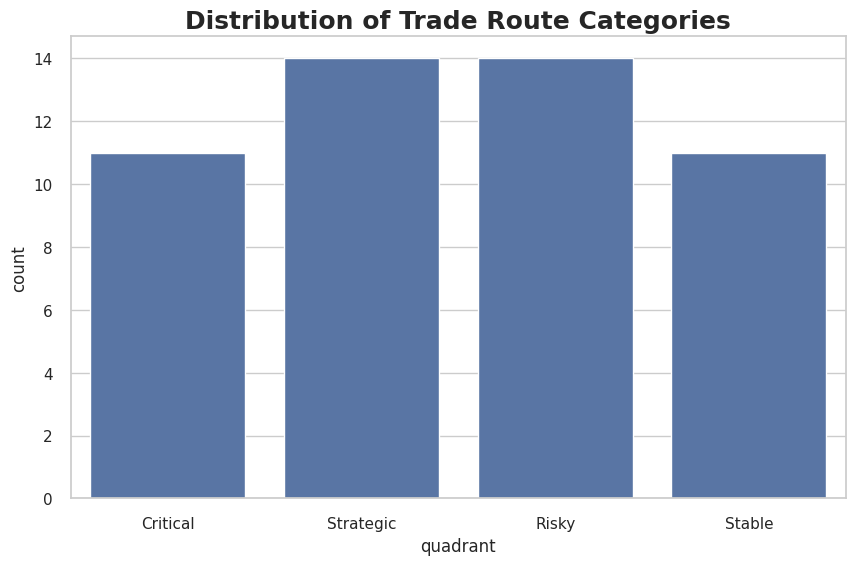

In [53]:
route_summary["quadrant"] = np.where(
    (route_summary["trade_volume_tonnes"] > volume_threshold) &
    (route_summary["risk_score"] > rish_threshold),
    "Critical",
    np.where(
        (route_summary["trade_volume_tonnes"] > volume_threshold),
        "Strategic",
        np.where(
            (route_summary["risk_score"] > rish_threshold),
            "Risky",
            "Stable"
        )
    )
)

plt.figure(figsize=(10,6))

sns.countplot(
    data=route_summary,
    x="quadrant",
    order=[
        "Critical",
        "Strategic",
        "Risky",
        "Stable"
    ]
)

plt.title(
    "Distribution of Trade Route Categories",
    fontsize=18,
    fontweight="bold"
)

plt.show()

**Explanation**

Think of a city's road network.

Some roads are:

* Busy and safe
* Quiet and dangerous
* Busy and dangerous

The busy and dangerous roads deserve the most attention because disruptions there affect the largest number of people.

The same logic applies to global trade routes.

**Key Findings**

* Most trade routes fall into the Stable category.
* A small subset of routes accounts for the highest concentration of risk.
* Critical routes combine strategic importance with elevated disruption exposure.
* These routes should receive priority monitoring and contingency planning.

**Chapter 7 Summary: Trade Route Risk Matrix**

*What Did We Learn?*

Not all trade routes contribute equally to global supply chains, and not all routes face the same level of disruption risk.

By combining economic importance (trade volume) with operational risk indicators (congestion, weather disruptions, and geopolitical instability), we developed a Trade Route Risk Matrix that identifies where strategic importance and vulnerability intersect.

The analysis revealed that while many routes remain relatively stable, a smaller subset of routes carries both high trade volumes and elevated risk levels. These routes represent the most critical points of failure within the global supply chain network.

# ***Chapter 8: Forecasting Future Disruptions***

**Business Question**
>Can future shipping delays be predicted before they happen?

**Why This Matters**

Unexpected delays cost billions of dollars every year.

If companies can anticipate disruptions before they occur, they can:

* Reroute shipments
* Adjust inventory levels
* Secure alternative suppliers
* Reduce operational costs

The goal is to determine whether supply chain indicators contain enough information to forecast future delays.

***Analytical Approach***

We will build a:

**XGBoost Regressor**

*Target:*
>shipping_delay_days

*Features:*
> port_congestion_index
> fuel_cost_index
> commodity_price_index
> weather_disruption_score
> geopolitical_risk_score
> container_availability_index
> trade_volume_tonnes

*Why XGBoost?*
> Industry standard
> Handles nonlinear relationships
> Excellent performance on tabular data
> Widely used in logistics forecasting

***Step 1: Prepare Dataset***

In [54]:
features = [
    "port_congestion_index",
    "fuel_cost_index",
    "commodity_price_index",
    "weather_disruption_score",
    "geopolitical_risk_score",
    "container_availability_index",
    "trade_volume_tonnes"
]

target = "shipping_delay_days"

forecast_df = (weekly_route_operations[features +[target]].dropna())

forecast_df.shape

(31300, 8)